In [3]:
import networkx as nx
import matplotlib.pyplot as plt
from ortools.sat.python import cp_model

In [4]:
model = cp_model.CpModel()

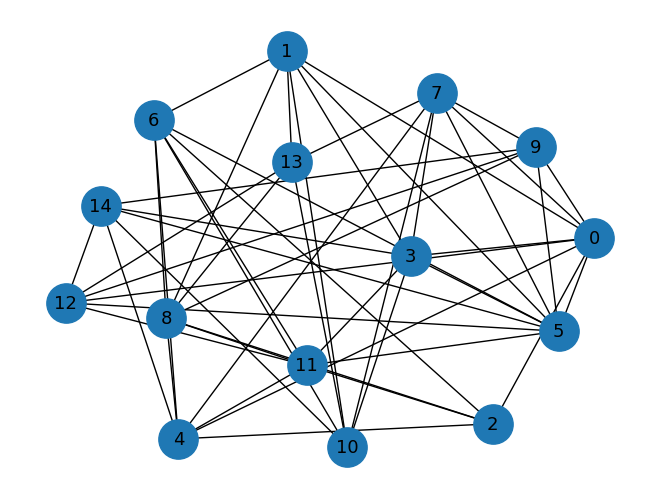

In [79]:

nodes = range(15)
edges = {
    (2, 4), (2, 6), (2, 8), (2, 11), (4, 6), (4, 8),
    (4, 11), (6, 8), (6, 11), (8, 11), (0, 1), (0, 3),
    (0, 5), (0, 7), (0, 9), (0, 12), (1, 3), (1, 5),
    (1, 10), (1, 13), (3, 5), (3, 7), (3, 10), (3, 14),
    (5, 7), (5, 9), (5, 12), (5, 14), (7, 9), (7, 10),
    (7, 13), (9, 12), (9, 14), (10, 13), (10, 14), (12, 13),
    (12, 14), (0, 2), (0, 4), (1, 6), (1, 8), (3, 11), (5, 6),
    (5, 11), (7, 4), (9, 8), (10, 6), (12, 11), (13, 8), (14, 4),
}

graph = nx.Graph()
graph.add_nodes_from(nodes)
graph.add_edges_from(edges)
pos = nx.arf_layout(graph)

nx.draw(graph,pos=pos,  with_labels=True, node_size=800, font_size=13) 
plt.show()

In [80]:
x = {
    i: model.NewBoolVar(f"x[{i}]")    
    for i in nodes
}

In [81]:
for i in nodes:
    for j in nodes:
        if i < j and (i,j) not in edges:
            model.Add(x[i]+x[j] <= 1)

In [82]:
model.Maximize(sum(x[i] for i in nodes))

In [83]:
solver = cp_model.CpSolver()
status = solver.Solve(model)

In [84]:
print(status)
clique = [
    i for i in nodes
    if solver.Value(x[i]) == 1
]
print(clique)
# print(max(list(nx.find_cliques(graph)), key=len))

CpSolverStatus.OPTIMAL
[2, 4, 6, 8, 11]


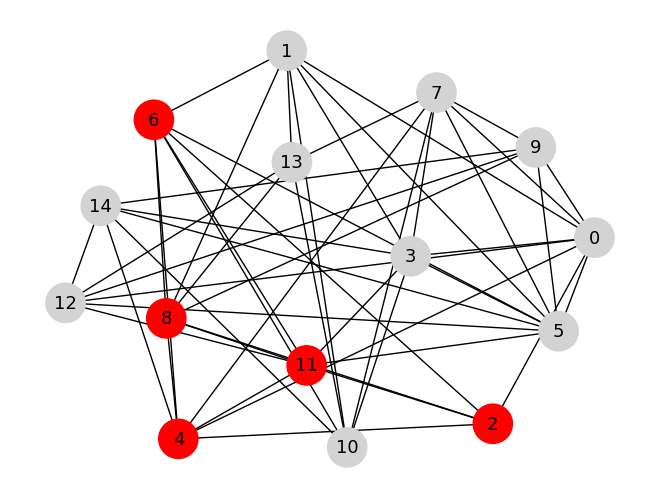

In [85]:
node_colors = [] 
for node in graph.nodes:
    if node in clique:
        node_colors.append("red")
    else:
        node_colors.append("lightgray")
nx.draw(graph,pos=pos,node_color = node_colors,  with_labels=True, node_size=800, font_size=13) 